In [1]:
import os
import cv2
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, 
                                     Conv2DTranspose, concatenate, 
                                     BatchNormalization, Activation, add)
from tensorflow.keras.callbacks import ModelCheckpoint
import tensorflow.keras.backend as K
from sklearn.model_selection import KFold
from IPython.display import FileLink

2026-04-06 15:04:09.265628: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775487849.287573   48835 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775487849.294141   48835 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775487849.311927   48835 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775487849.311956   48835 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775487849.311959   48835 computation_placer.cc:177] computation placer alr

In [2]:
IMG_HEIGHT = 256  # [cite: 249]
IMG_WIDTH = 256   # [cite: 249]
N_CHANNELS = 1    # Ảnh huỳnh quang là Grayscale 
BATCH_SIZE = 8    # Tập dữ liệu 97 ảnh 
EPOCHS = 150      # Huấn luyện cố định [cite: 319]
N_SPLITS = 5      # 5-Fold Cross Validation [cite: 335]
LEARNING_RATE = 1e-3
ALPHA = 1.67      # Hệ số alpha chuẩn [cite: 201]

# Đường dẫn tập dữ liệu ISBI-2009 (Murphy Lab) [cite: 245]
base_path = "/kaggle/input/datasets/quanhh42/multiresunet-datasets/ISBI2009"
img_dir = os.path.join(base_path, "images")
mask_dir = os.path.join(base_path, "masks")

In [3]:
def load_isbi2009_data():
    X, Y = [], []
    img_files = sorted(glob.glob(os.path.join(img_dir, "*.*")))
    print(f"Đang nạp {len(img_files)} ảnh từ ISBI-2009...")
    for f in tqdm(img_files, desc="Loading Images"):
        filename = os.path.basename(f)
        m_path = os.path.join(mask_dir, filename)
        if os.path.exists(m_path):
            img = cv2.imread(f, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT)) / 255.0
            msk = cv2.imread(m_path, cv2.IMREAD_GRAYSCALE)
            msk = cv2.resize(msk, (IMG_WIDTH, IMG_HEIGHT)) / 255.0
            X.append(img)
            Y.append(np.round(msk, 0))
    return np.expand_dims(np.array(X), -1), np.expand_dims(np.array(Y), -1)

X, Y = load_isbi2009_data()
print(f"Dữ liệu sẵn sàng! X shape: {X.shape}, Y shape: {Y.shape}")

Đang nạp 97 ảnh từ ISBI-2009...


Loading Images: 100%|██████████| 97/97 [00:04<00:00, 20.67it/s]


Dữ liệu sẵn sàng! X shape: (97, 256, 256, 1), Y shape: (97, 256, 256, 1)


In [4]:
def jacard(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f + y_pred_f - y_true_f * y_pred_f)
    return intersection / (union + K.epsilon())

def dice_coef(y_true, y_pred):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2.0 * intersection + K.epsilon()) / (K.sum(y_true_f) + K.sum(y_pred_f) + K.epsilon())

In [5]:
def build_unet_baseline(input_shape=(IMG_HEIGHT, IMG_WIDTH, N_CHANNELS)):
    def conv_block(i, f):
        x = Conv2D(f, (3,3), padding='same', activation='relu', kernel_initializer='he_normal')(i)
        return Conv2D(f, (3,3), padding='same', activation='relu', kernel_initializer='he_normal')(x)
    inputs = Input(input_shape)
    s1 = conv_block(inputs, 32); p1 = MaxPooling2D((2,2))(s1)
    s2 = conv_block(p1, 64); p2 = MaxPooling2D((2,2))(s2)
    s3 = conv_block(p2, 128); p3 = MaxPooling2D((2,2))(s3)
    s4 = conv_block(p3, 256); p4 = MaxPooling2D((2,2))(s4)
    b5 = conv_block(p4, 512)
    u6 = Conv2DTranspose(256, (2,2), strides=(2,2), padding='same')(b5)
    d6 = conv_block(concatenate([u6, s4], 3), 256)
    u7 = Conv2DTranspose(128, (2,2), strides=(2,2), padding='same')(d6)
    d7 = conv_block(concatenate([u7, s3], 3), 128)
    u8 = Conv2DTranspose(64, (2,2), strides=(2,2), padding='same')(d7)
    d8 = conv_block(concatenate([u8, s2], 3), 64)
    u9 = Conv2DTranspose(32, (2,2), strides=(2,2), padding='same')(d8)
    d9 = conv_block(concatenate([u9, s1], 3), 32)
    return Model(inputs, Conv2D(1, (1,1), activation='sigmoid')(d9), name='UNet')

In [6]:
def build_multiresunet(height=IMG_HEIGHT, width=IMG_WIDTH, n_channels=N_CHANNELS):
    def conv2d_bn(x, f, r, c, act='relu'):
        x = Conv2D(f, (r, c), padding='same', use_bias=False)(x)
        x = BatchNormalization(axis=3, scale=False)(x) # [cite: 211]
        return Activation(act)(x) if act else x
    def MultiResBlock(U, inp): # [cite: 132, 203]
        W = ALPHA * U
        f1, f2, f3 = int(W*0.167), int(W*0.333), int(W*0.5)
        short = conv2d_bn(inp, f1+f2+f3, 1, 1, act=None)
        c3 = conv2d_bn(inp, f1, 3, 3); c5 = conv2d_bn(c3, f2, 3, 3); c7 = conv2d_bn(c5, f3, 3, 3)
        return Activation('relu')(add([short, concatenate([c3, c5, c7], 3)]))
    def ResPath(f, length, inp): # [cite: 188, 209]
        out = conv2d_bn(inp, f, 3, 3)
        out = add([conv2d_bn(inp, f, 1, 1, act=None), out])
        out = Activation('relu')(BatchNormalization(axis=3)(out))
        for _ in range(length - 1):
            short = conv2d_bn(out, f, 1, 1, act=None)
            out = conv2d_bn(out, f, 3, 3)
            out = Activation('relu')(add([short, out]))
            out = BatchNormalization(axis=3)(out)
        return out
    inputs = Input((height, width, n_channels))
    m1 = MultiResBlock(32, inputs); p1 = MaxPooling2D((2,2))(m1); r1 = ResPath(32, 4, m1)
    m2 = MultiResBlock(64, p1); p2 = MaxPooling2D((2,2))(m2); r2 = ResPath(64, 3, m2)
    m3 = MultiResBlock(128, p2); p3 = MaxPooling2D((2,2))(m3); r3 = ResPath(128, 2, m3)
    m4 = MultiResBlock(256, p3); p4 = MaxPooling2D((2,2))(m4); r4 = ResPath(256, 1, m4)
    m5 = MultiResBlock(512, p4)
    u6 = concatenate([Conv2DTranspose(256, (2,2), strides=(2,2), padding='same')(m5), r4], 3); m6 = MultiResBlock(256, u6)
    u7 = concatenate([Conv2DTranspose(128, (2,2), strides=(2,2), padding='same')(m6), r3], 3); m7 = MultiResBlock(128, u7)
    u8 = concatenate([Conv2DTranspose(64, (2,2), strides=(2,2), padding='same')(m7), r2], 3); m8 = MultiResBlock(64, u8)
    u9 = concatenate([Conv2DTranspose(32, (2,2), strides=(2,2), padding='same')(m8), r1], 3); m9 = MultiResBlock(32, u9)
    return Model(inputs, Conv2D(1, (1,1), activation='sigmoid')(m9), name='MultiResUNet')

In [7]:
def train_and_evaluate(build_fn, model_name, X, Y, kf):
    os.makedirs(f'models_{model_name}', exist_ok=True)
    metrics_log = {'jaccard': [], 'dice': [], 'histories': []}
    best_fold, best_jac = 0, 0
    for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
        print(f"\n--- {model_name.upper()} | Fold {fold}/5 ---")
        K.clear_session()
        model = build_fn()
        model.compile(optimizer=tf.keras.optimizers.Adam(LEARNING_RATE), loss='binary_crossentropy', metrics=[jacard, dice_coef])
        path = f'models_{model_name}/{model_name}_isbi2009_fold{fold}_best.weights.h5'
        checkpoint = ModelCheckpoint(path, monitor='val_jacard', mode='max', save_best_only=True, save_weights_only=True, verbose=0)
        history = model.fit(X[train_idx], Y[train_idx], validation_data=(X[val_idx], Y[val_idx]), 
                            batch_size=BATCH_SIZE, epochs=EPOCHS, callbacks=[checkpoint], verbose=0)
        metrics_log['histories'].append(history)
        metrics_log['jaccard'].append(max(history.history['val_jacard']))
        metrics_log['dice'].append(max(history.history['val_dice_coef']))
        print(f"Fold {fold}: Jaccard = {metrics_log['jaccard'][-1]*100:.2f}%")
        if metrics_log['jaccard'][-1] > best_jac: best_jac, best_fold = metrics_log['jaccard'][-1], fold
    return metrics_log, best_fold

In [8]:
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=3)
unet_results, unet_best_fold = train_and_evaluate(build_unet_baseline, 'unet', X, Y, kf)
multi_results, multi_best_fold = train_and_evaluate(build_multiresunet, 'multiresunet', X, Y, kf)


--- UNET | Fold 1/5 ---


I0000 00:00:1775487864.933533   48835 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1775487871.593890   48903 service.cc:152] XLA service 0x79ec88003a30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775487871.593933   48903 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1775487872.710630   48903 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1775487882.839212   48903 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-04-06 15:04:46.116813: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight System

Fold 1: Jaccard = 89.68%

--- UNET | Fold 2/5 ---
Fold 2: Jaccard = 90.05%

--- UNET | Fold 3/5 ---


2026-04-06 15:09:58.570634: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 15:09:58.806615: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 15:10:08.486167: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 15:10:08.721680: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Fold 3: Jaccard = 90.92%

--- UNET | Fold 4/5 ---
Fold 4: Jaccard = 88.81%

--- UNET | Fold 5/5 ---
Fold 5: Jaccard = 89.51%

--- MULTIRESUNET | Fold 1/5 ---
Fold 1: Jaccard = 90.41%

--- MULTIRESUNET | Fold 2/5 ---
Fold 2: Jaccard = 91.28%

--- MULTIRESUNET | Fold 3/5 ---
Fold 3: Jaccard = 91.20%

--- MULTIRESUNET | Fold 4/5 ---
Fold 4: Jaccard = 88.85%

--- MULTIRESUNET | Fold 5/5 ---
Fold 5: Jaccard = 90.44%


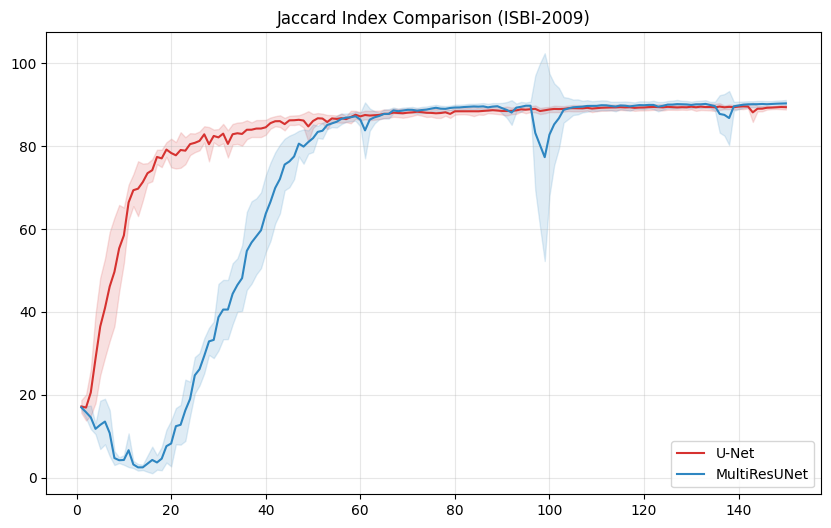

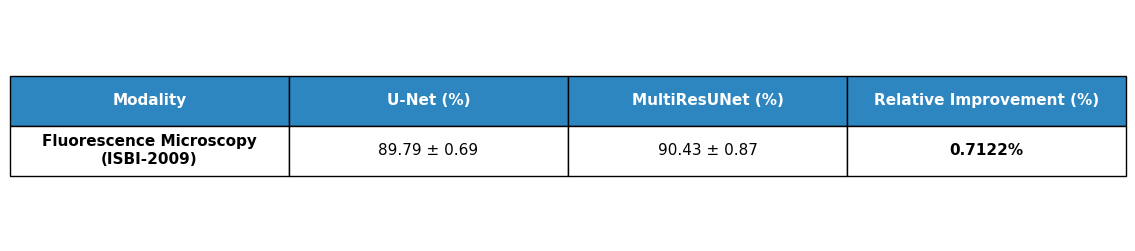


✅ HOÀN TẤT TOÀN BỘ QUY TRÌNH ISBI-2009!


/kaggle/working/ISBI2009_Final_Results.zip

In [9]:
# A. Learning Curve
unet_data = np.array([h.history['val_jacard'] for h in unet_results['histories']]) * 100
multi_data = np.array([h.history['val_jacard'] for h in multi_results['histories']]) * 100
plt.figure(figsize=(10, 6))
plt.plot(range(1, 151), np.mean(unet_data, 0), label='U-Net', color='#D63230')
plt.fill_between(range(1, 151), np.mean(unet_data, 0)-np.std(unet_data, 0), np.mean(unet_data, 0)+np.std(unet_data, 0), color='#D63230', alpha=0.15)
plt.plot(range(1, 151), np.mean(multi_data, 0), label='MultiResUNet', color='#2E86C1')
plt.fill_between(range(1, 151), np.mean(multi_data, 0)-np.std(multi_data, 0), np.mean(multi_data, 0)+np.std(multi_data, 0), color='#2E86C1', alpha=0.15)
plt.title('Jaccard Index Comparison (ISBI-2009)'); plt.legend(loc='lower right'); plt.grid(True, alpha=0.3)
plt.savefig('ISBI2009_Learning_Curve.png', dpi=300); plt.show()

# B. Table 4 Style Results
u_m, u_s = np.mean(unet_results['jaccard'])*100, np.std(unet_results['jaccard'])*100
m_m, m_s = np.mean(multi_results['jaccard'])*100, np.std(multi_results['jaccard'])*100
rel_imp = ((m_m - u_m) / u_m) * 100
columns = ("Modality", "U-Net (%)", "MultiResUNet (%)", "Relative Improvement (%)")
data = [["Fluorescence Microscopy\n(ISBI-2009)", f"{u_m:.2f} ± {u_s:.2f}", f"{m_m:.2f} ± {m_s:.2f}", f"{rel_imp:.4f}%"]]
fig, ax = plt.subplots(figsize=(12, 3)); ax.axis('tight'); ax.axis('off')
table = ax.table(cellText=data, colLabels=columns, loc='center', cellLoc='center')
table.auto_set_font_size(False); table.set_fontsize(11); table.scale(1.2, 3)
for (r, c), cell in table.get_celld().items():
    if r == 0: cell.set_text_props(weight='bold', color='white'); cell.set_facecolor('#2E86C1')
    if r > 0 and (c == 0 or c == 3): cell.set_text_props(weight='bold')
plt.savefig('ISBI2009_Official_Table.png', dpi=300); plt.show()

# --- Nén và hoàn tất ---
!zip -q -r ISBI2009_Final_Results.zip models_multiresunet/ models_unet/ *.png
print("\n✅ HOÀN TẤT TOÀN BỘ QUY TRÌNH ISBI-2009!")
display(FileLink('ISBI2009_Final_Results.zip'))

In [10]:
# import matplotlib.pyplot as plt
# import numpy as np

# # 1. Trích xuất và tính toán thông số từ kết quả huấn luyện (trong RAM)
# u_jac_mean = np.mean(unet_results['jaccard']) * 100
# u_jac_std  = np.std(unet_results['jaccard']) * 100
# m_jac_mean = np.mean(multi_results['jaccard']) * 100
# m_jac_std  = np.std(multi_results['jaccard']) * 100

# # Công thức tính Relative Improvement (%) theo bài báo 
# rel_improvement = ((m_jac_mean - u_jac_mean) / u_jac_mean) * 100

# # 2. Chuẩn bị dữ liệu theo cấu trúc Table 4 của bài báo 
# # Cột: Modality | U-Net (%) | MultiResUNet (%) | Relative Improvement (%)
# columns = ("Modality", "U-Net (%)", "MultiResUNet (%)", "Relative Improvement (%)")
# data = [
#     [
#         "Electron Microscopy\n(ISBI-2012)", 
#         f"{u_jac_mean:.2f} ± {u_jac_std:.2f}", 
#         f"{m_jac_mean:.2f} ± {m_jac_std:.2f}", 
#         f"{rel_improvement:.4f}%"
#     ]
# ]

# # 3. Vẽ bảng bằng Matplotlib
# fig, ax = plt.subplots(figsize=(12, 3))
# ax.axis('tight')
# ax.axis('off')

# # Tạo bảng với định dạng cellLoc='center' để canh giữa toàn bộ
# table = ax.table(cellText=data, colLabels=columns, loc='center', cellLoc='center')

# # Tùy chỉnh font và kích thước để giống văn bản học thuật
# table.auto_set_font_size(False)
# table.set_fontsize(11)
# table.scale(1.2, 3) # Kéo dãn chiều cao hàng để nhìn thoáng hơn

# # Đổ màu Header và định dạng chữ đậm cho các mốc quan trọng
# for (row, col), cell in table.get_celld().items():
#     if row == 0: # Dòng tiêu đề
#         cell.set_text_props(weight='bold', color='white')
#         cell.set_facecolor('#2E86C1') # Màu xanh đặc trưng MultiResUNet
#     if row > 0:
#         if col == 0 or col == 3: # Cột tên Dataset hoặc cột Improvement
#             cell.set_text_props(weight='bold')
#         if col == 3: # Highlight cột Improvement
#             cell.set_text_props(color='#D63230') # Màu đỏ để gây chú ý

# plt.title('Comparison of Segmentation Performance on ISBI-2012 Dataset', 
#           fontsize=14, pad=30, fontweight='bold')

# plt.tight_layout()
# plt.savefig('ISBI2012_Official_Style_Table.png', dpi=300, bbox_inches='tight')
# plt.show()

# print(f"✅ Đã cập nhật bảng báo cáo! Chỉ số cải thiện: {rel_improvement:.4f}%")

In [11]:
# import os
# from IPython.display import FileLink

# # 1. Tên file nén đầu ra
# zip_filename = 'Ket_Qua_Nghiên_Cuu_ISBI2012.zip'

# # 2. Dọn dẹp file cũ nếu tồn tại để giải phóng bộ nhớ
# if os.path.exists(zip_filename):
#     os.remove(zip_filename)

# print(f"--- Đang bắt đầu đóng gói kết quả ---")

# # 3. Sử dụng lệnh zip của Linux để nén đích danh:
# # - models_multiresunet/ và models_unet/: Chứa toàn bộ weights (.h5) của 5-Fold
# # - *.png: Chứa toàn bộ biểu đồ Learning Curve, K-Fold, Table và Demo Comparison
# # - *.pkl: Chứa dữ liệu history (nếu có lưu) để vẽ lại biểu đồ sau này
# !zip -q -r {zip_filename} models_multiresunet/ models_unet/ *.png *.pkl

# print(f"✅ Đã nén xong toàn bộ dữ liệu!")
# print(f"Bạn hãy click vào đường link bên dưới để tải file về máy:")

# # 4. Hiển thị link tải trực tiếp
# display(FileLink(zip_filename))

In [12]:
# import numpy as np
# import matplotlib.pyplot as plt

# def plot_paper_learning_curve(unet_histories, multi_histories, metric='val_jacard', title_metric='Validation Jaccard (%)'):
#     """
#     Hàm móc dữ liệu từ lịch sử huấn luyện 5-Fold và vẽ biểu đồ so sánh có bóng mờ (Variance)
#     Đã đảo thứ tự Legend: U-Net nằm trên, MultiResUNet nằm dưới
#     """
#     print("Đang trích xuất dữ liệu và vẽ biểu đồ...")
    
#     # 1. Trích xuất dữ liệu của 5 Folds (Chuyển sang dạng phần trăm %)
#     unet_data = np.array([h.history[metric] for h in unet_histories]) * 100
#     multi_data = np.array([h.history[metric] for h in multi_histories]) * 100
    
#     # Lấy mốc trục X là số Epochs (1 đến 150)
#     epochs = np.arange(1, unet_data.shape[1] + 1)
    
#     # 2. Tính Trung bình (Mean) và Độ lệch chuẩn (Std)
#     unet_mean = np.mean(unet_data, axis=0)
#     unet_std = np.std(unet_data, axis=0)
    
#     multi_mean = np.mean(multi_data, axis=0)
#     multi_std = np.std(multi_data, axis=0)
    
#     # 3. Tiến hành vẽ biểu đồ
#     plt.figure(figsize=(10, 6))
    
#     # VẼ U-NET TRƯỚC ĐỂ LÊN TOP LEGNED (Đường màu Đỏ)
#     plt.plot(epochs, unet_mean, label='U-Net', color='#D63230', linewidth=2)
#     plt.fill_between(epochs, 
#                      unet_mean - unet_std, 
#                      unet_mean + unet_std, 
#                      color='#D63230', alpha=0.2, linewidth=0)

#     # VẼ MULTIRESUNET SAU ĐỂ NẰM DƯỚI LEGEND (Đường màu Xanh dương)
#     plt.plot(epochs, multi_mean, label='MultiResUNet', color='#2E86C1', linewidth=2)
#     plt.fill_between(epochs, 
#                      multi_mean - multi_std, 
#                      multi_mean + multi_std, 
#                      color='#2E86C1', alpha=0.2, linewidth=0)
    
    
#     # 4. Trang trí biểu đồ chuẩn bài báo (Paper-style)
#     plt.title('Jaccard Index Comparison (CVC-ClinicDB Data)', fontsize=14)
#     plt.xlabel('Epochs', fontsize=12)
#     plt.ylabel(title_metric, fontsize=12)
    
#     # Lưới kẻ (Grid) mờ
#     plt.grid(True, linestyle='--', alpha=0.7)
    
#     # Ghi chú (Legend) ở góc dưới bên phải
#     plt.legend(loc='lower right', fontsize=11, framealpha=0.9)
    
#     # Giới hạn trục Y và X cho đẹp mắt
#     plt.xlim(0, len(epochs) + 5)
    
#     plt.tight_layout()
#     plt.savefig('Paper_Style_Learning_Curve.png', dpi=300, bbox_inches='tight')
#     plt.show()
#     print("Đã lưu biểu đồ thành công: 'Paper_Style_Learning_Curve.png'")

# # ============================================================================
# # GỌI HÀM VẼ BIỂU ĐỒ 
# # ============================================================================
# # Vẽ cho Jaccard Index
# plot_paper_learning_curve(unet_histories, multi_histories, metric='val_jacard', title_metric='Validation Jaccard (%)')

# # Nếu muốn vẽ thêm cho Dice thì bạn bỏ dấu '#' ở dòng dưới nha:
# # plot_paper_learning_curve(unet_histories, multi_histories, metric='val_dice_coef', title_metric='Validation Dice (%)')

In [13]:
# import os
# from IPython.display import FileLink

# print("1. Đang dọn dẹp file ZIP bị lỗi để giải phóng ổ cứng...")
# # Xóa file ZIP rác khổng lồ (nếu có)
# if os.path.exists('/kaggle/working/Backup_Models_CVC.zip'):
#     os.remove('/kaggle/working/Backup_Models_CVC.zip')

# print("2. Đang nén lại dữ liệu (Tốc độ bàn thờ bằng Linux)...")
# # Dùng lệnh zip của Linux nén đích danh các thư mục và file cần thiết (bỏ qua file ẩn rác)
# !zip -q -r Backup_Models_CVC.zip models_multiresunet/ models_unet/ *.png *.pkl

# print("✅ Đã giải cứu ổ cứng và nén xong! Click vào link bên dưới để tải:")
# display(FileLink('Backup_Models_CVC.zip'))